# Aircraft Wildlife Strikes, 1990-2015

Ova baza podataka nam govori o incidentima sudara divljih životinja sa zrakoplovima. Skup podataka sadrži zapis o svakom prijavljenom sudaru divljih životinja sa svim vrstama zrakoplova između 1990. i 2015. godine.

# Biblioteke


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from scipy.stats import chi2_contingency
import math

# Učitavanje podataka

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Uvod u Podatkovnu Znanost

/content/drive/MyDrive/Uvod u Podatkovnu Znanost


In [4]:
data = pd.read_csv('database.csv')

<ipython-input-4-0872d265e962>:1: DtypeWarning: Columns (9,12,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('database.csv')


Dataset koji se koristi u ovom projektu može se naći na [linku](https://www.kaggle.com/datasets/faa/wildlife-strikes/data):

# Obrada i čišćenje podataka

In [5]:
data.head() # Prikaz prvih 5 redova skupa podataka

,Record ID,Incident Year,Incident Month,Incident Day,Operator ID,Operator,Aircraft,Aircraft Type,Aircraft Make,Aircraft Model,...,Fuselage Strike,Fuselage Damage,Landing Gear Strike,Landing Gear Damage,Tail Strike,Tail Damage,Lights Strike,Lights Damage,Other Strike,Other Damage
0,127128,1990,1,1,DAL,DELTA AIR LINES,B-757-200,A,148,26,...,0,0,0,0,1,1,0,0,0,0
1,129779,1990,1,1,HAL,HAWAIIAN AIR,DC-9,A,583,90,...,0,0,0,0,0,0,0,0,1,0
2,129780,1990,1,2,UNK,UNKNOWN,UNKNOWN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,2258,1990,1,3,MIL,MILITARY,A-10A,A,345,NaN,...,0,0,0,0,0,0,0,0,0,0
4,2257,1990,1,3,MIL,MILITARY,F-16,A,561,NaN,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data.tail() # Prikaz zadnjih 5 redova skupa podataka

,Record ID,Incident Year,Incident Month,Incident Day,Operator ID,Operator,Aircraft,Aircraft Type,Aircraft Make,Aircraft Model,...,Fuselage Strike,Fuselage Damage,Landing Gear Strike,Landing Gear Damage,Tail Strike,Tail Damage,Lights Strike,Lights Damage,Other Strike,Other Damage
174099,366091,2015,9,30,SWA,SOUTHWEST AIRLINES,B-737-700,A,148,42.0,...,0,0,0,0,0,0,0,0,0,0
174100,365902,2015,9,30,SWA,SOUTHWEST AIRLINES,B-737-700,A,148,42.0,...,0,0,0,0,0,0,0,0,0,0
174101,365903,2015,9,30,BUS,BUSINESS,CITATIONJET,A,226,49.0,...,1,1,0,0,0,0,0,0,0,0
174102,366046,2015,9,30,QXE,HORIZON AIR,DHC8 DASH 8,A,303,10.0,...,1,0,0,0,0,0,0,0,0,0
174103,365823,2015,9,30,AWI,AIR WISCONSIN AIRLINES,CRJ100/200,A,188,10.0,...,0,0,0,0,0,0,0,0,1,0


In [7]:
print(f"Data shape: {data.shape}")

Data shape: (174104, 66)


Dakle, podatci su spremljeni u 174 104 retka sa 66 stupaca

In [8]:
print("Stupci:")
for col in data.columns:
  print("\t", col) # Prikaz stupaca skupa podataka

Stupci:
	 Record ID
	 Incident Year
	 Incident Month
	 Incident Day
	 Operator ID
	 Operator
	 Aircraft
	 Aircraft Type
	 Aircraft Make
	 Aircraft Model
	 Aircraft Mass
	 Engine Make
	 Engine Model
	 Engines
	 Engine Type
	 Engine1 Position
	 Engine2 Position
	 Engine3 Position
	 Engine4 Position
	 Airport ID
	 Airport
	 State
	 FAA Region
	 Warning Issued
	 Flight Phase
	 Visibility
	 Precipitation
	 Height
	 Speed
	 Distance
	 Species ID
	 Species Name
	 Species Quantity
	 Flight Impact
	 Fatalities
	 Injuries
	 Aircraft Damage
	 Radome Strike
	 Radome Damage
	 Windshield Strike
	 Windshield Damage
	 Nose Strike
	 Nose Damage
	 Engine1 Strike
	 Engine1 Damage
	 Engine2 Strike
	 Engine2 Damage
	 Engine3 Strike
	 Engine3 Damage
	 Engine4 Strike
	 Engine4 Damage
	 Engine Ingested
	 Propeller Strike
	 Propeller Damage
	 Wing or Rotor Strike
	 Wing or Rotor Damage
	 Fuselage Strike
	 Fuselage Damage
	 Landing Gear Strike
	 Landing Gear Damage
	 Tail Strike
	 Tail Damage
	 Lights Strike
	 

In [9]:
data.info()  # Informacije o skupu podataka

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174104 entries, 0 to 174103
Data columns (total 66 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Record ID             174104 non-null  int64  
 1   Incident Year         174104 non-null  int64  
 2   Incident Month        174104 non-null  int64  
 3   Incident Day          174104 non-null  int64  
 4   Operator ID           174104 non-null  object 
 5   Operator              174104 non-null  object 
 6   Aircraft              174104 non-null  object 
 7   Aircraft Type         133074 non-null  object 
 8   Aircraft Make         131051 non-null  object 
 9   Aircraft Model        122439 non-null  object 
 10  Aircraft Mass         127320 non-null  float64
 11  Engine Make           123434 non-null  float64
 12  Engine Model          121988 non-null  object 
 13  Engines               127342 non-null  float64
 14  Engine Type           127282 non-null  object 
 15  

In [10]:
print(f"Broj redaka s bar jednom NaN vrijednosti: {sum(data.isna().any(axis=1))}")
print(f"Broj stupaca s bar jednom NaN vrijednosti: {sum(data.isna().any(axis=0))}")

Broj redaka s bar jednom NaN vrijednosti: 174104
Broj stupaca s bar jednom NaN vrijednosti: 27


In [11]:
print(f"Stupci u kojima su NaN vrijednosti: {list(data.columns[data.isna().any()])}")

Stupci u kojima su NaN vrijednosti: ['Aircraft Type', 'Aircraft Make', 'Aircraft Model', 'Aircraft Mass', 'Engine Make', 'Engine Model', 'Engines', 'Engine Type', 'Engine1 Position', 'Engine2 Position', 'Engine3 Position', 'Engine4 Position', 'Airport', 'State', 'FAA Region', 'Warning Issued', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Speed', 'Distance', 'Species Name', 'Species Quantity', 'Flight Impact', 'Fatalities', 'Injuries']


In [12]:
nan_counts = data.isna().sum()   # brojanje NaN vrijednosti po stupcima
nan_counts = nan_counts[nan_counts > 0] # filtriramo stupce tako da odbacujemo one koji nemaju NaN vrijednosti
nan_percentage = (data.isna().sum() / len(data) * 100).round(2)    # računanje postotka svakog stupca s NaN vrijednostima zaokruženo na dvije decimale
nan_info = pd.DataFrame({"NaN Counts": nan_counts, "NaN Percentage (%)": nan_percentage[nan_counts.index]}) # kreiranje tablice s brojem i postotkom NaN vrijednosti
print(nan_info)

                  NaN Counts  NaN Percentage (%)
Aircraft Type          41030               23.57
Aircraft Make          43053               24.73
Aircraft Model         51665               29.67
Aircraft Mass          46784               26.87
Engine Make            50670               29.10
Engine Model           52116               29.93
Engines                46762               26.86
Engine Type            46822               26.89
Engine1 Position       47911               27.52
Engine2 Position       55389               31.81
Engine3 Position      162445               93.30
Engine4 Position      171012               98.22
Airport                  290                0.17
State                  21976               12.62
FAA Region             18902               10.86
Warning Issued         97686               56.11
Flight Phase           55302               31.76
Visibility             64171               36.86
Precipitation          85782               49.27
Height              

Prvi korak: Izbacivanje svih stupaca koji imaju više od 50% NaN vrijednosti

In [13]:
threshold = len(data) * 0.5  # prag se postavlja na 50% ukupnog broja redaka u skupu podataka
data.dropna(axis=1, thresh=threshold, inplace=True) # brisanje svih stupaca sa više od 50% NaN vrijednosti

print(f"Novi broj stupaca: {data.shape[1]}")
print(f"Novi broj redaka: {data.shape[0]}")
print(f"Data shape: {data.shape}")

Novi broj stupaca: 60
Novi broj redaka: 174104
Data shape: (174104, 60)


In [14]:
print(f"Broj redaka s bar jednom NaN vrijednosti: {sum(data.isna().any(axis=1))}")
print(f"Broj stupaca s bar jednom NaN vrijednosti: {sum(data.isna().any(axis=0))}")

Broj redaka s bar jednom NaN vrijednosti: 140067
Broj stupaca s bar jednom NaN vrijednosti: 21


Drugi korak: Izbacivanje svih onih redaka koji imaju 4 ili više NaN vrijednosti

In [15]:
data.dropna(axis=0, thresh=data.shape[1]-4+1, inplace=True)

In [16]:
print(f"Stupci u kojima su još ostale NaN vrijednosti: {list(data.columns[data.isna().any()])}")

Stupci u kojima su još ostale NaN vrijednosti: ['Aircraft Make', 'Aircraft Model', 'Engine Make', 'Engine Model', 'Engine Type', 'Engine1 Position', 'Engine2 Position', 'Airport', 'State', 'FAA Region', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Distance', 'Species Name', 'Species Quantity', 'Flight Impact']


In [17]:
print(f"Broj redaka s bar jednom NaN vrijednosti nakon čišćenja: {sum(data.isna().any(axis=1))}")
print(f"Broj stupaca s bar jednom NaN vrijednosti nakon čišćenja: {sum(data.isna().any(axis=0))}")

Broj redaka s bar jednom NaN vrijednosti nakon čišćenja: 64883
Broj stupaca s bar jednom NaN vrijednosti nakon čišćenja: 18


Treći korak: Popunjavanje vrijednosti s onim vrijednostima u retku ispred

In [18]:
data.fillna(axis=0, method='ffill', inplace=True)

<ipython-input-18-cf4ca13cf539>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(axis=0, method='ffill', inplace=True)


In [19]:
print(f"Broj redaka s bar jednom NaN vrijednosti nakon čišćenja: {sum(data.isna().any(axis=1))}")
print(f"Broj stupaca s bar jednom NaN vrijednosti nakon čišćenja: {sum(data.isna().any(axis=0))}")

Broj redaka s bar jednom NaN vrijednosti nakon čišćenja: 3
Broj stupaca s bar jednom NaN vrijednosti nakon čišćenja: 3


In [20]:
print(f"Stupci u kojima su još ostale NaN vrijednosti: {list(data.columns[data.isna().any()])}")

Stupci u kojima su još ostale NaN vrijednosti: ['Visibility', 'Precipitation', 'Flight Impact']


Četvrti korak: Izbacivanje preostalih redaka s NaN vrijednostima

In [21]:
data.dropna(inplace=True)

In [22]:
print(f"Broj redaka s bar jednom NaN vrijednosti nakon čišćenja: {sum(data.isna().any(axis=1))}")
print(f"Broj stupaca s bar jednom NaN vrijednosti nakon čišćenja: {sum(data.isna().any(axis=0))}")
print(f"Broj redaka i stupaca nakon uklanjanja: {data.shape}")

Broj redaka s bar jednom NaN vrijednosti nakon čišćenja: 0
Broj stupaca s bar jednom NaN vrijednosti nakon čišćenja: 0
Broj redaka i stupaca nakon uklanjanja: (98917, 60)


# Analiza podataka

Usporedba sudara divljih životinja sa zrakoplovima po godini

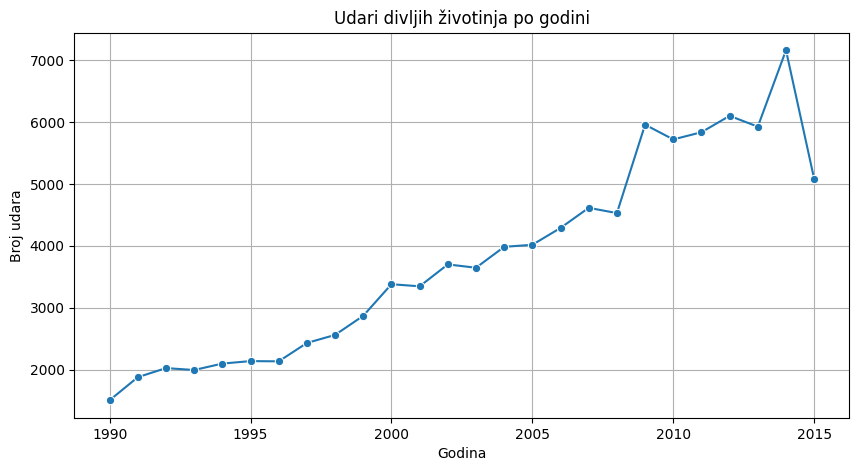

In [23]:
yearly_trends = data.groupby('Incident Year').size()

# Vizualizacija
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, marker='o')
plt.title("Udari divljih životinja po godini")
plt.xlabel("Godina")
plt.ylabel("Broj udara")
plt.grid()
plt.show()

Usporedba sudara divljih životinja sa zrakoplovima po mjesecima u godini

<ipython-input-24-a1b9d5e12ad2>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_trends.index, y=monthly_trends.values, palette='viridis')


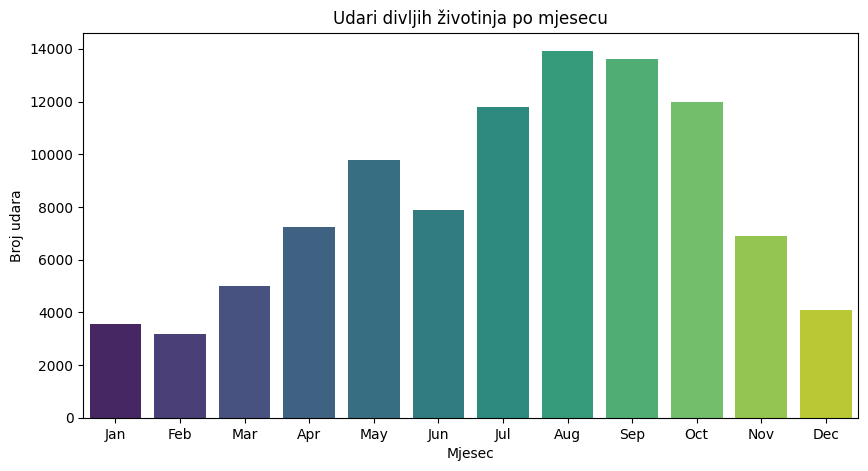

In [24]:
monthly_trends = data.groupby('Incident Month').size()

# Vizualizacija
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_trends.index, y=monthly_trends.values, palette='viridis')
plt.title("Udari divljih životinja po mjesecu")
plt.xlabel("Mjesec")
plt.ylabel("Broj udara")
plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])
plt.show()

Usporedba sudara divljih životinja sa zrakoplovima po danima u tjednu

In [25]:
# Stvaranje novog stupca datuma kako bi mogli analizirati udare divljih životinja po danu u tjednu
data['Incident Date'] = pd.to_datetime(data['Incident Year'].astype(str) + '-' +
                                       data['Incident Month'].astype(str) + '-' +
                                       data['Incident Day'].astype(str),
                                       errors='coerce')

<ipython-input-26-c55815421ea6>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_of_week_trends.index, y=day_of_week_trends.values, palette='coolwarm')


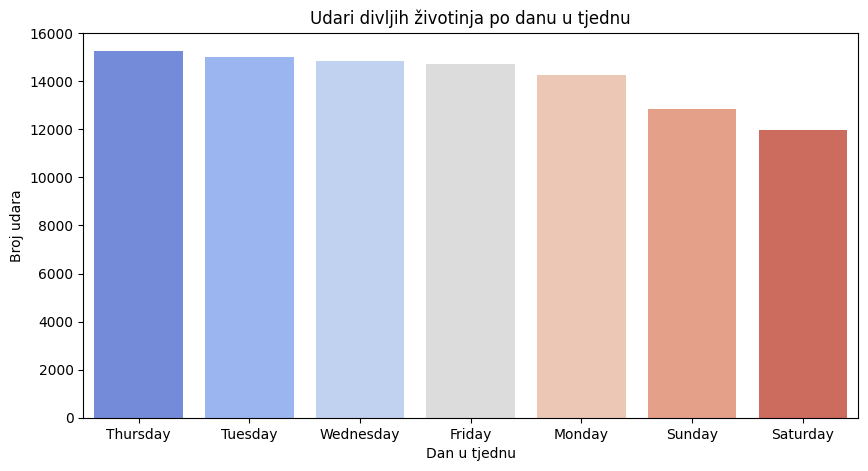

In [26]:
data['Day of Week'] = data['Incident Date'].dt.day_name() # Izdvajanje dana u tjednu iz datuma
day_of_week_trends = data['Day of Week'].value_counts() # Grupiranje po danu u tjednu

# Vizualizacija
plt.figure(figsize=(10, 5))
sns.barplot(x=day_of_week_trends.index, y=day_of_week_trends.values, palette='coolwarm')
plt.title("Udari divljih životinja po danu u tjednu")
plt.xlabel("Dan u tjednu")
plt.ylabel("Broj udara")

plt.show()

Prikaz aerodroma sa najviše prijavljenih sudara divljih životinja sa zrakoplovima

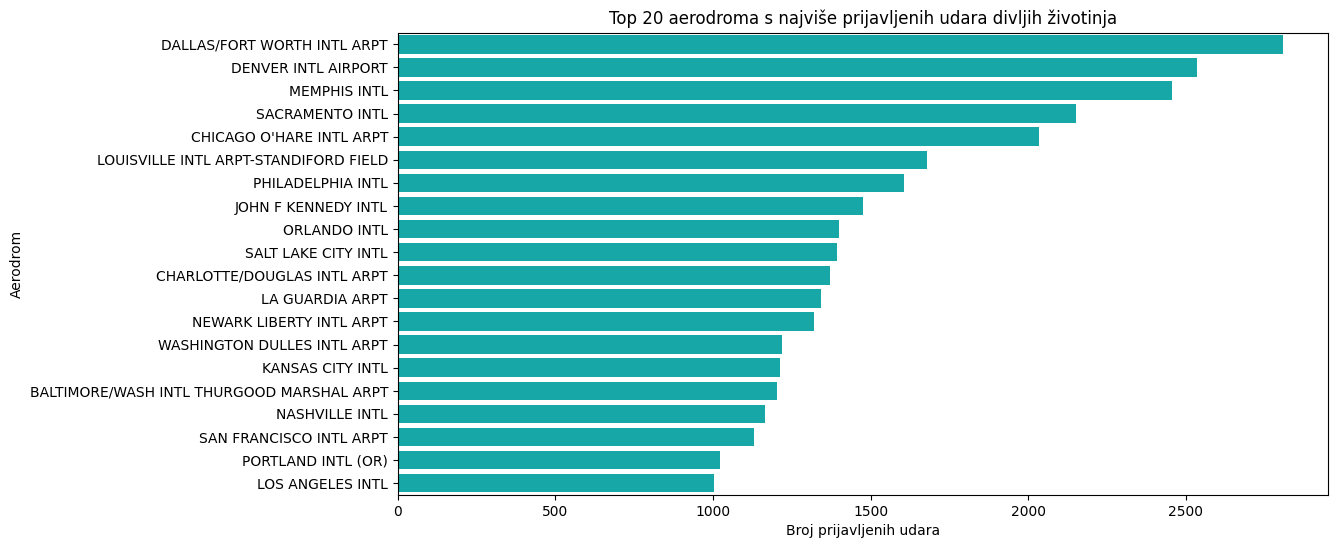

In [27]:
airport_counts = data['Airport'].value_counts() # Grupiranje po aerodromu i prebrojavanje udara u njemu
top_airports = airport_counts.head(20) # Prikaži top 20 aerodroma s najviše prijavljenih sudara divljih životinja sa zrakoplovima

# Vizualizacija
plt.figure(figsize=(12, 6))
sns.barplot(x=top_airports.values, y=top_airports.index, color="c")
plt.xlabel("Broj prijavljenih udara")
plt.ylabel("Aerodrom")
plt.title("Top 20 aerodroma s najviše prijavljenih udara divljih životinja")
plt.show()

Prikaz vrste divljih životinja koje najčešće uzrokuju sudare

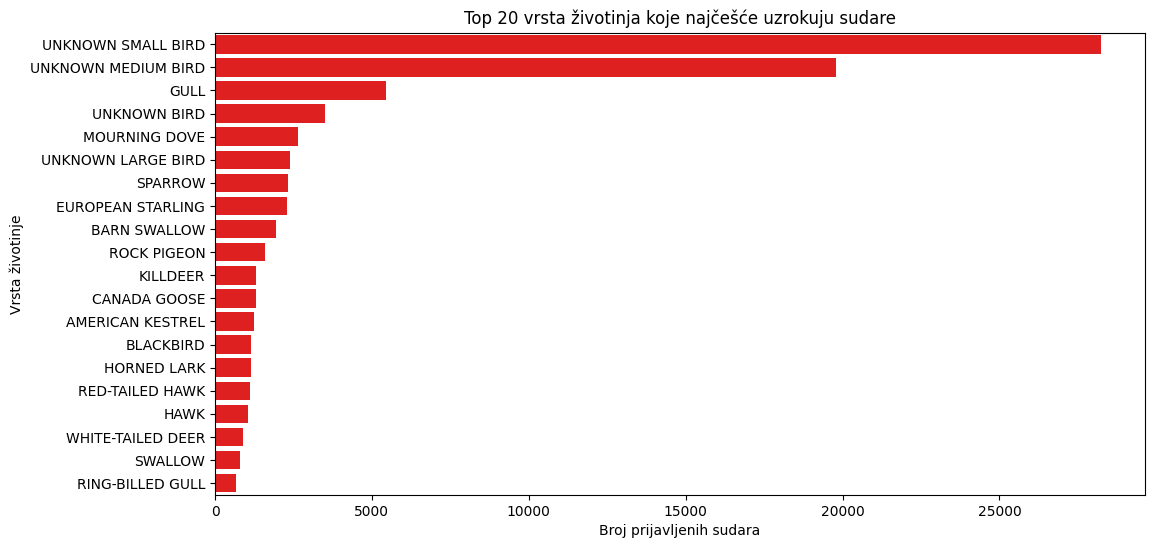

In [28]:
species_counts = data['Species Name'].value_counts() # Grupiranje po vrsti životinje i prebrojavanje
top_species = species_counts.head(20) # Prikaži top 20 vrsta životinja koje najčešće uzrokuju sudare

# Vizualizacija
plt.figure(figsize=(12, 6))
sns.barplot(x=top_species.values, y=top_species.index, color="red")
plt.xlabel("Broj prijavljenih sudara")
plt.ylabel("Vrsta životinje")
plt.title("Top 20 vrsta životinja koje najčešće uzrokuju sudare")
plt.show()

Udio tipova zrakoplova u sudarima sa divljim životinjama

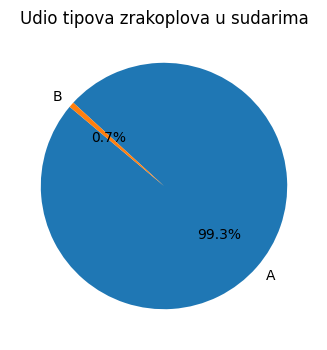

In [29]:
top_aircraft = data['Aircraft Type'].value_counts()  # Grupiranje po tipu zrakoplova i prebrojavanje

# Vizualizacija u obliku pie charta
plt.figure(figsize=(8, 4))
plt.pie(
    top_aircraft,
    labels=top_aircraft.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Udio tipova zrakoplova u sudarima")
plt.show()

Raspodjela visine sudara zrakoplova sa divljim životinjama

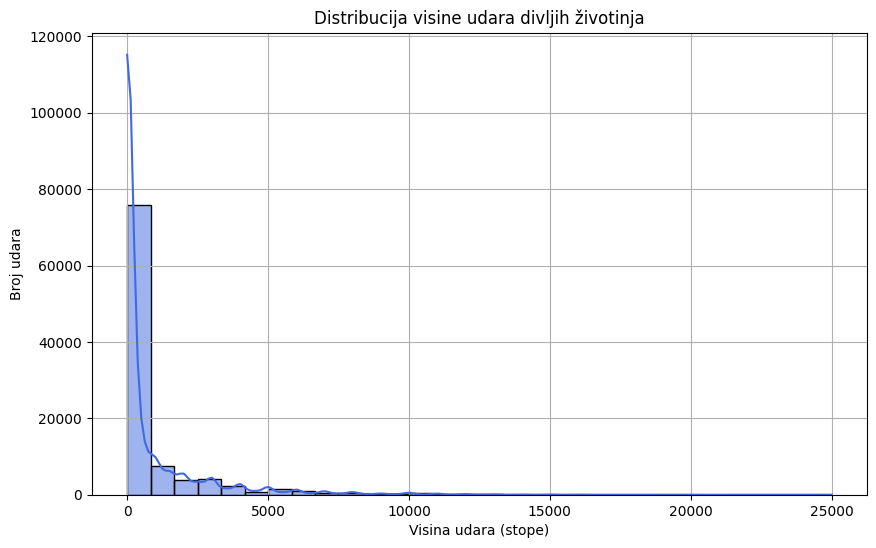

In [30]:
height_data = data['Height'] # Provjera visine udara

# Vizualizacija
plt.figure(figsize=(10, 6))
sns.histplot(height_data, bins=30, kde=True, color="royalblue")
plt.xlabel("Visina udara (stope)")
plt.ylabel("Broj udara")
plt.title("Distribucija visine udara divljih životinja")
plt.grid(True)
plt.show()

Visina udara je u bazi podataka prikazana u stopama (1 stopa = 0.3048 metara)

In [31]:
mean_height = round(data['Height'].mean(), 2)  # prosječna vrijednost visine udara divljih životinja
std_height=round(data['Height'].std(), 2)     # standardna devijacija visine udara divljih životinja

print(mean_height)
print(std_height)

821.64
1806.82


Prikaz država (saveznih) sa najviše sudara divljih životinja sa zrakoplovima

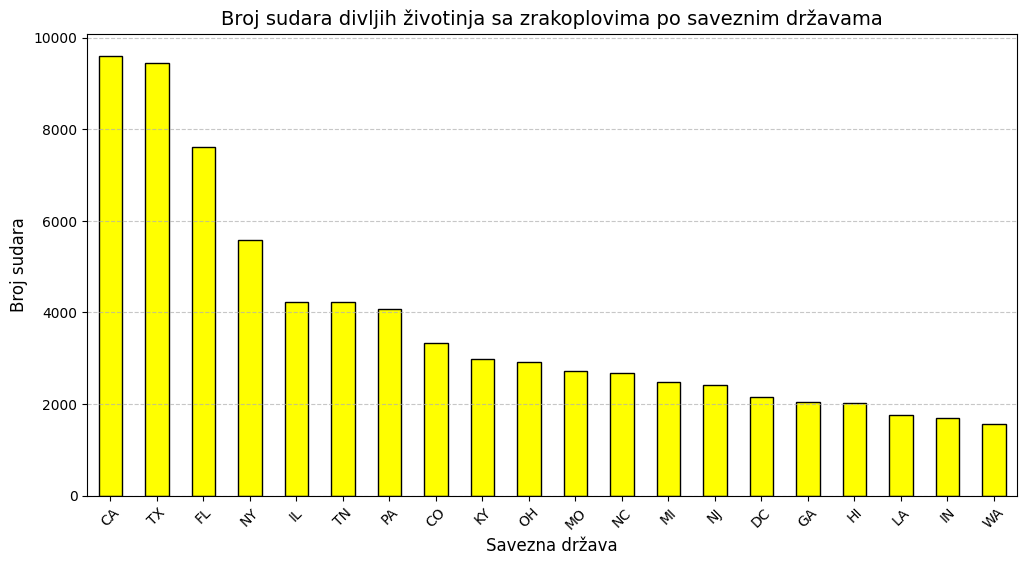

In [32]:
state_counts = data["State"].value_counts()  # Grupiranje po državama i prebrojavanje
top_state_counts = state_counts.head(20) # Prikaži top 20 država sa najviše sudara divljih životinja sa zrakoplovima

# Vizualizacija
plt.figure(figsize=(12, 6))
top_state_counts.plot(kind="bar", color="yellow", edgecolor="black")
plt.title("Broj sudara divljih životinja sa zrakoplovima po saveznim državama", fontsize=14)
plt.xlabel("Savezna država", fontsize=12)
plt.ylabel("Broj sudara", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Raspodjela sudara divljih životinja sa zrakoplovima koji uzrokuju štetu na zrakoplovu te onih koji prođu bez štete

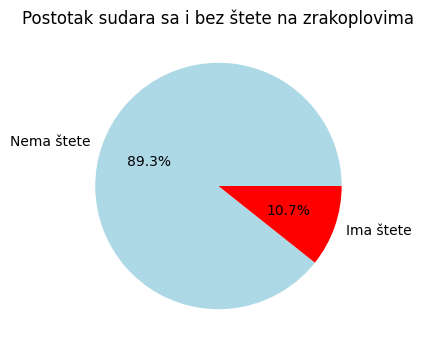

In [33]:
damage_counts = data["Aircraft Damage"].value_counts() # Prebrojavanje sudara sa štetnim posljedicama i onima bez

# Zamjena vrijednosti 0 i 1 odgovarajućim oznakama "Nema štete" i "Ima štete"
labels = ["Nema štete", "Ima štete"]
sizes = [damage_counts.get(0, 0), damage_counts.get(1, 0)]

# Vizualizacija - pie chart
plt.figure(figsize=(8,4))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=["lightblue", "red"])
plt.title("Postotak sudara sa i bez štete na zrakoplovima")
plt.show()

Raspodijela udara i oštećenja po dijelovima zrakoplova te njihova korelacija

In [34]:
# Izdvajanje relevantnih stupaca koji su vezani uz udare i oštećenja
strike_columns = [
    "Radome Strike", "Windshield Strike", "Nose Strike", "Engine1 Strike", "Engine2 Strike",
    "Engine3 Strike", "Engine4 Strike", "Propeller Strike", "Wing or Rotor Strike",
    "Fuselage Strike", "Landing Gear Strike", "Tail Strike", "Lights Strike", "Other Strike"
]    # Stupci vezani uz udare na zrakoplov

damage_columns = [
    "Radome Damage", "Windshield Damage", "Nose Damage", "Engine1 Damage", "Engine2 Damage",
    "Engine3 Damage", "Engine4 Damage", "Propeller Damage", "Wing or Rotor Damage",
    "Fuselage Damage", "Landing Gear Damage", "Tail Damage", "Lights Damage", "Other Damage"
]   # Stupci vezani uz oštećenja zrakoplova

# Zbrajanje ukupnog broja udara i oštećenja po dijelovima zrakoplova
strike_counts = data[strike_columns].sum()
damage_counts = data[damage_columns].sum()

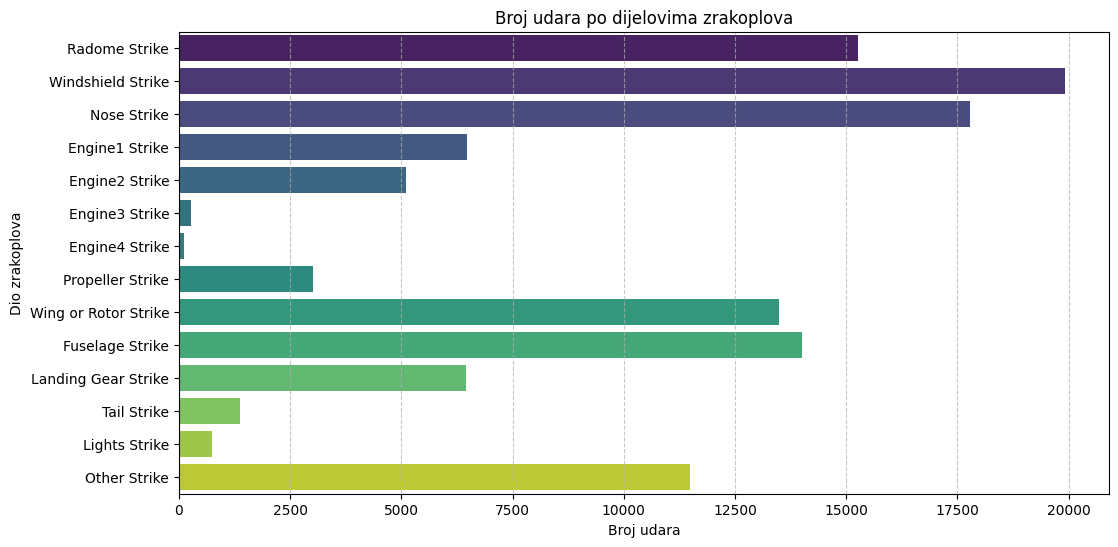

In [35]:
# Vizualizacija za sudare zrakoplova sa divljim životinjama po dijelovima
plt.figure(figsize=(12, 6))
sns.barplot(x=strike_counts, y=strike_columns, hue=strike_columns, palette="viridis", legend=False)
plt.xlabel("Broj udara")
plt.ylabel("Dio zrakoplova")
plt.title("Broj udara po dijelovima zrakoplova")
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Dodajemo mrežu za lakše čitanje
plt.show()

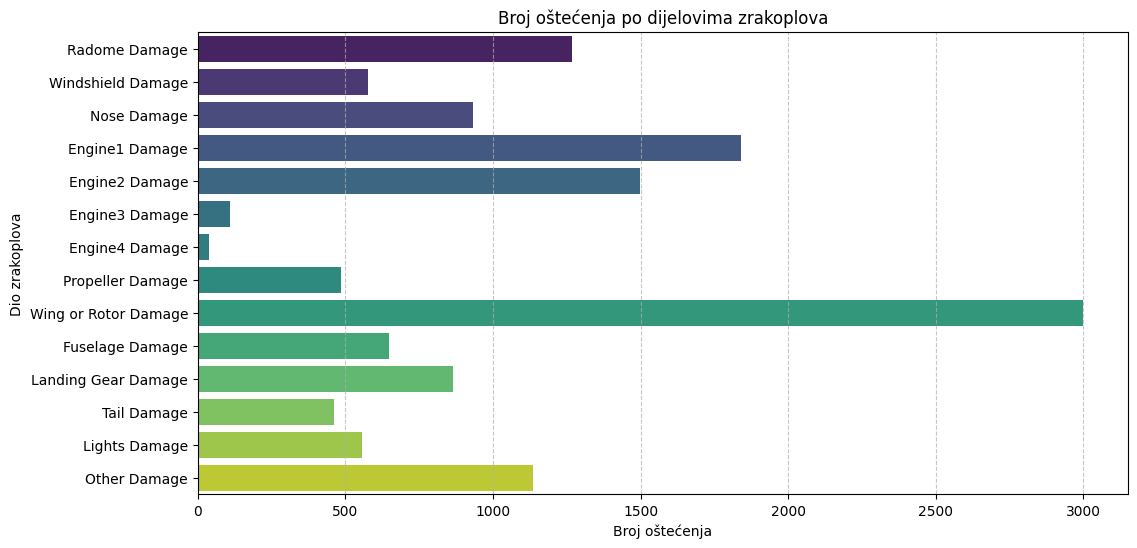

In [36]:
# Vizualizacija oštećenja po dijelovima zrakoplova
plt.figure(figsize=(12, 6))
sns.barplot(x=damage_counts, y=damage_columns, hue=damage_columns, palette="viridis", legend=False)
plt.xlabel("Broj oštećenja")
plt.ylabel("Dio zrakoplova")
plt.title("Broj oštećenja po dijelovima zrakoplova")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Ono što se može primijetiti je da iako je najviše na udaru vjetrobransko staklo zrakoplova da nije onda i automatski najoštećeniji dio zrakoplova, štoviše neki dijelovi imaju znatno veći broj oštećenja iako imaju puno manje udara nego vjetrobransko staklo

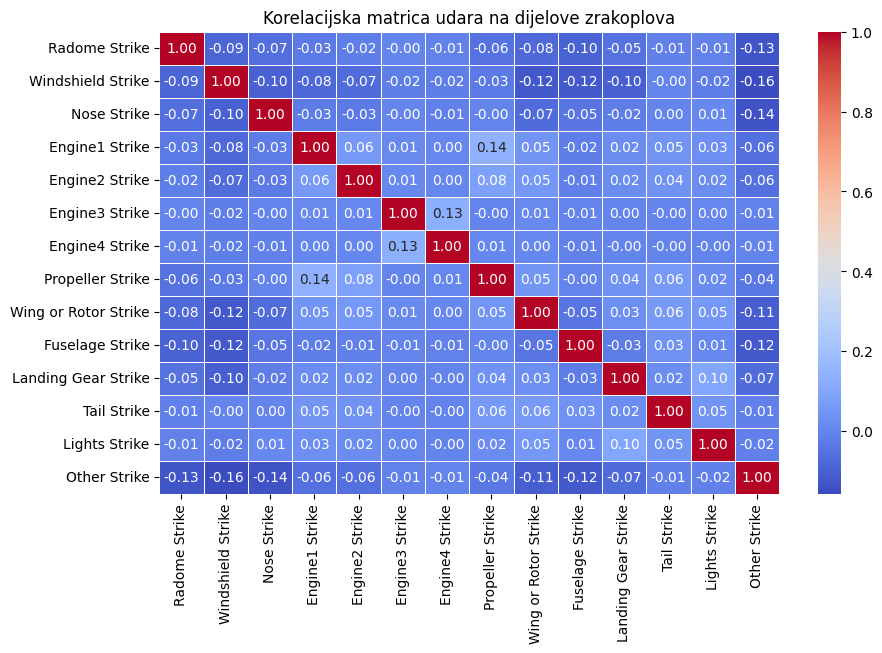

In [37]:
data_selected_strike = data[strike_columns] # Odabir stupaca sa udarima na zrakoplov za korelaciju
data_corr_strike = data_selected_strike.corr() # Kreiranje korelacijske matrice

# Prikaz korelacijske matrice udara na dijelove zrakoplova
plt.figure(figsize=(10, 6))
sns.heatmap(data_corr_strike, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelacijska matrica udara na dijelove zrakoplova")
plt.show()

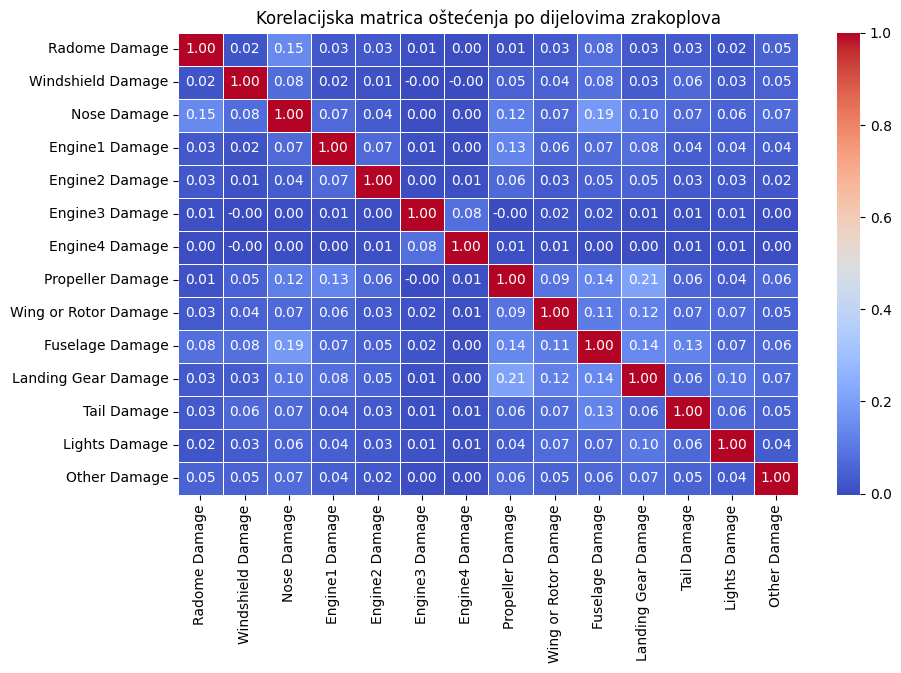

In [38]:
data_selected_damage = data[damage_columns] # Odabir stupaca sa oštećenjima na zrakoplovima za korelaciju
data_corr_damage = data_selected_damage.corr() # Kreiranje korelacijske matrice

# Prikaz korelacijske matrice oštećenja po dijelovima zrakoplova
plt.figure(figsize=(10, 6))
sns.heatmap(data_corr_damage, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelacijska matrica oštećenja po dijelovima zrakoplova")
plt.show()

Ono što se može zaključiti iz priloženih matrica korelacije je da su većina udara kao i oštećenja na različite dijelove zrakoplova slabo povezani ili neovisni

# Procjenitelji i intervali pouzdanosti

In [39]:
sample_A = data[data['Aircraft Type'] == 'A'].sample(50) # Odabir slučajnog uzorka od 50 zapisa za zrakoplov tipa A
sample_B= data[data['Aircraft Type'] == 'B'].sample(50) # Odabir slučajnog uzorka od 50 zapisa za zrakoplov tipa B

In [40]:
mean_A = round(sample_A['Height'].mean(), 2)  # Prosječna vrijednost za stupac "Height" uzorak zrakoplova tipa A
std_A = round(sample_A['Height'].std(), 2)    # Standardna devijacija za stupac "Height" za uzorak zrakoplova tipa A

mean_B = round(sample_B['Height'].mean(), 2)  # Prosječna vrijednost za stupac "Height" za uzorak zrakoplova tipa B
std_B = round(sample_B['Height'].std(), 2)    # Standardna devijacija za stupac "Height" za uzorak zrakoplova tipa B

print(mean_A)
print(std_A)
print(mean_B)
print(std_B)

1139.0
1865.72
858.1
803.03


In [41]:
z = {'90%': 1.65, '95%':1.96, '99%':2.58}

# Računanje 90%, 95% i 99% intervala pouzdanosti za parametar prosječne vrijednosti stupca "Height" za oba tipa zrakoplova
for pouzdanost in z.keys():
  err_A = z[pouzdanost]*std_A/math.sqrt(200)
  err_B = z[pouzdanost]*std_B/math.sqrt(200)
  print(f"{pouzdanost} pouzdani interval povjerenja\n\tZrakoplov tipa A: <{mean_A-err_A:.2f}, {mean_A+err_A:.2f}>\tZrakoplov tipa B: <{mean_B-err_B:.2f}, {mean_B+err_B:.2f}>")

90% pouzdani interval povjerenja
	Zrakoplov tipa A: <921.32, 1356.68>	Zrakoplov tipa B: <764.41, 951.79>
95% pouzdani interval povjerenja
	Zrakoplov tipa A: <880.42, 1397.58>	Zrakoplov tipa B: <746.81, 969.39>
99% pouzdani interval povjerenja
	Zrakoplov tipa A: <798.63, 1479.37>	Zrakoplov tipa B: <711.60, 1004.60>


# Testiranje hipoteza

Pogledat ćemo ovisnost visine sa slučajevima s i bez oštećenja zrakoplova

In [42]:
# Odabir podataka
group1 = data[data["Aircraft Damage"] == 1]["Height"]
group2 = data[data["Aircraft Damage"] == 0]["Height"]

**$H_0$:** Nema značajne razlike u visini udara između slučajeva sa i bez oštećenja zrakoplova
<br>
**$H_1$:** Postoji značajna razlika u visini između slučajeva sa i bez oštećenja zrakoplova

Provjera jesu li podatci za visinu udara normalno distribuirani

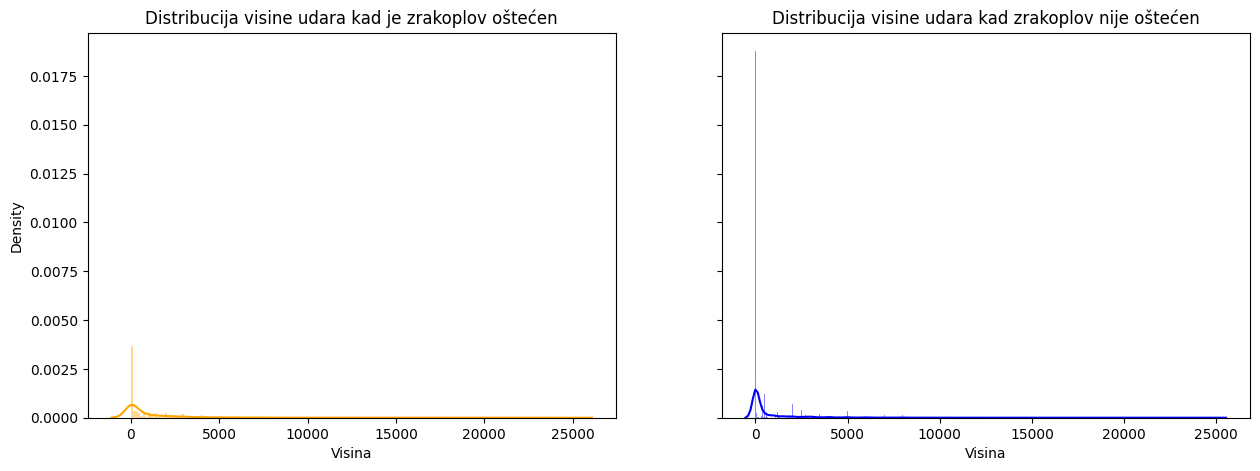

In [43]:
# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
axes[0].set_title('Distribucija visine udara kad je zrakoplov oštećen')
axes[0].set_xlabel("Visina")
sns.histplot(group1, stat='density', alpha=0.5, color='orange', edgecolor='white',ax=axes[0])
sns.kdeplot(group1,  color='orange', ax=axes[0])
axes[1].set_title('Distribucija visine udara kad zrakoplov nije oštećen')
axes[1].set_xlabel("Visina")
sns.histplot(group2, stat='density', alpha=0.5, color='blue', edgecolor='white', ax=axes[1])
sns.kdeplot(group2,  color='blue', ax=axes[1]);

In [44]:
statistic, pvalue = stats.normaltest(group1)
print(f"pvalue: {pvalue}")
print(f"pvalue < 0.05: {pvalue < 0.05}")

pvalue: 0.0
pvalue < 0.05: True


In [45]:
statistic, pvalue = stats.normaltest(group2)
print(f"pvalue: {pvalue}")
print(f"pvalue < 0.05: {pvalue < 0.05}")

pvalue: 0.0
pvalue < 0.05: True


p-vrijednost je manja od 0.05. To znači da podaci nisu normalno distribuirani. Moramo odustati od parametarskog testa te odabrati neparametarski test - Mann Whitney U test.

In [46]:
statistic, pvalue = stats.mannwhitneyu(group1, group2)
print(f"pvalue: {pvalue}")
print(f"pvalue < 0.05: {pvalue < 0.05}")

pvalue: 1.144744267782726e-134
pvalue < 0.05: True


p-vrijednost je manja od 0.05. Odbacujemo $H_0$, tj. zaključujemo: **Postoji značajna razlika u visini između slučajeva sa i bez oštećenja zrakoplova.**

Pogledajmo sada ovisnost oštećenja aviona sa fazom leta. Koristit ćemo chi-kvadrat (chi-square) test.

**$H_0$:** Nema značajne povezanosti između oštećenja zrakoplova i faze leta
<br>
**$H_1$:** Postoji značajna povezanost između oštećenja zrakoplova i faze leta

In [47]:
contingency_table = pd.crosstab(data["Aircraft Damage"], data["Flight Phase"]) # kreiranje kontigencijske tablice
# Izvođenje chi-kvadrat testa
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-kvadrat statistika: {chi2_stat}") # koliko je stvarna raspodjela podataka različita od očekivane
print(f"p-vrijednost: {p_value}")

Chi-kvadrat statistika: 1365.5089910315426
p-vrijednost: 2.772587267530424e-287


p-vrijednost je manja od 0.05. Odbacujemo $H_0$, tj. zaključujemo: **Postoji značajna povezanost između oštećenja zrakoplova i faze leta.**

# Grupiranje

Grupiranje podataka visine udara i udaljenosti od piste pomoću algoritama KMeans i DBSCAN. Udaljenost od piste je u bazi podataka prikazana u miljama (1 milja = 1.609344 kilometra).

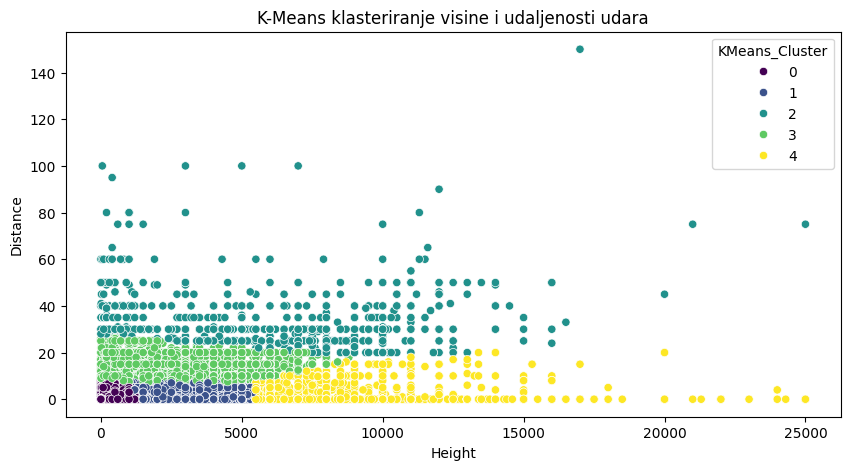

In [48]:
selected_data = data[['Height', 'Distance']] # odabir stupaca za klasteriranje
# Normalizacija podataka
scaler = StandardScaler()  # Standardizacija podataka
data_scaled = scaler.fit_transform(selected_data) # primjena skaliranja
# KMeans klasteriranje
kmeans = KMeans(n_clusters=5, random_state=42)  # podjela podataka u 5 klastera
data["KMeans_Cluster"] = kmeans.fit_predict(data_scaled) # treniranje i dodjela oznaka klastera

# Vizualizacija
plt.figure(figsize=(10, 5))
sns.scatterplot(x=data["Height"], y=data["Distance"], hue=data["KMeans_Cluster"], palette="viridis")
plt.title("K-Means klasteriranje visine i udaljenosti udara")
plt.show()

Većina podataka se nalazi u visini nižoj od 10 000 stopa i udaljenosti manjoj od 40 milja.

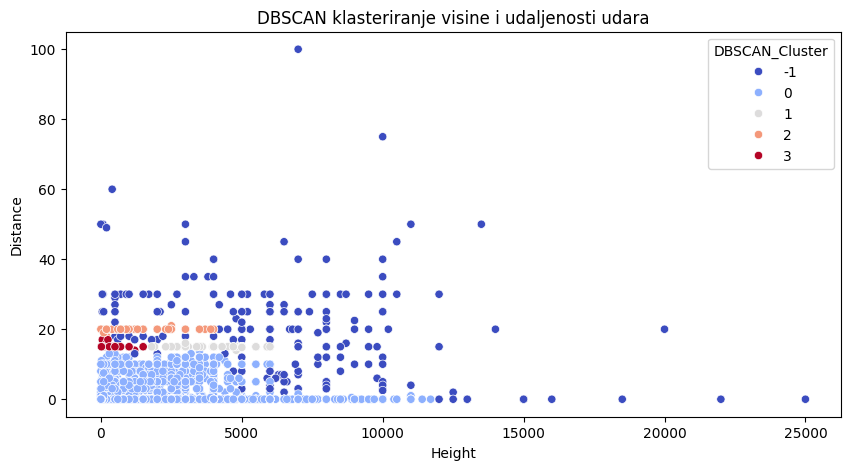

In [49]:
data_sampled = selected_data.sample(n=10000, random_state=42) # Odabir slučajnog uzorka od 10 000 zapisa od stupaca vezanih za visinu i udaljenost
# Normalizacija podataka
scaler = StandardScaler() # Standardizacija podataka
data_scaled_dbscan = scaler.fit_transform(data_sampled) # primjena skaliranja
# DBSCAN klasteriranje
dbscan = DBSCAN(eps=0.3, min_samples=10) # eps - maksimalna udaljenost između uzoraka istog klastera, za formiranje klastera potrebno minimalno 10 uzoraka
data_sampled["DBSCAN_Cluster"] = dbscan.fit_predict(data_scaled_dbscan) # treniranje DBSCAN-a i dodjeljivanje klastera podacima

# Vizualizacija
plt.figure(figsize=(10, 5))
sns.scatterplot(x=data_sampled["Height"], y=data_sampled["Distance"], hue=data_sampled["DBSCAN_Cluster"], palette="coolwarm")
plt.title("DBSCAN klasteriranje visine i udaljenosti udara")
plt.show()

Vidimo da se većina podataka nalazi u klasteru 0, klaster -1 označava outliere, podatke koje DBSCAN nije uspio dodijeliti ni u jedan klaster.